# 02 · Synthetic Supplier Quotes (calibrated to real data)
Supplier quotations are confidential, so they are **simulated** — but every quote inherits the real macro indices for its month and `unit_price` is an explicit function of them. Produced by `python -m src.data_generation`.

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40, "display.width", 160)
from src import config as C
print("project root:", ROOT)

project root: D:\proyectos\porsche intership\Price Intelligence\automotive-procurement-price-intelligence


In [2]:
q = pd.read_csv(C.RAW_QUOTES_CSV)
master = pd.read_csv(C.SUPPLIER_MASTER_CSV)
print(q.shape, '| suppliers:', q.supplier_id.nunique(), '| months:', q.groupby(['year','month']).ngroups)
q.head()

(4496, 24) | suppliers: 60 | months: 36
Out[2]: 
    quote_id supplier_id                supplier_name        component_type component_category country         region  year  month  order_volume  unit_price  \
0  QT-000001     SUP-001            Juno Systems Inc.  Suspension Component            Chassis     USA  North America  2022      1          1032      348.61   
1  QT-000002     SUP-002    Onyx Drivetrain Co., Ltd.        Battery Module      EV Components   China           Asia  2022      1           116    11994.56   
2  QT-000003     SUP-003  Zelos Electronics Co., Ltd.     Infotainment Unit        Electronics   China           Asia  2022      1           892     1048.94   
3  QT-000004     SUP-004         Drava Systems S.p.A.      Aluminum Casting         Powertrain   Italy         Europe  2022      1          2730      437.81   
4  QT-000005     SUP-005  Granta Components Co., Ltd.        Battery Module      EV Components   China           Asia  2022      1           118    151

,quote_id,supplier_id,supplier_name,component_type,component_category,country,region,year,month,order_volume,unit_price,raw_material_index,energy_cost_index,exchange_rate_index,lead_time_days,on_time_delivery_rate,defect_rate,warranty_claim_rate,supplier_capacity_utilization,logistics_cost,risk_score_external,contract_type,sustainability_score,final_awarded
0,QT-000001,SUP-001,Juno Systems Inc.,Suspension Component,Chassis,USA,North America,2022,1,1032,348.61,100.0,100.0,100.0,30,0.8290,0.0360,0.0212,0.733,6071.58,36.9,Annual Contract,51.3,0
1,QT-000002,SUP-002,"Onyx Drivetrain Co., Ltd.",Battery Module,EV Components,China,Asia,2022,1,116,11994.56,100.0,100.0,100.0,62,0.7877,0.0289,0.0151,0.863,5893.52,73.7,Spot,56.3,0
2,QT-000003,SUP-003,"Zelos Electronics Co., Ltd.",Infotainment Unit,Electronics,China,Asia,2022,1,892,1048.94,100.0,100.0,100.0,61,0.9422,0.0122,0.0074,0.783,6128.58,57.8,Multi-year Contract,75.0,0
3,QT-000004,SUP-004,Drava Systems S.p.A.,Aluminum Casting,Powertrain,Italy,Europe,2022,1,2730,437.81,100.0,100.0,100.0,13,0.9809,0.0066,0.0032,0.838,1269.66,34.3,Multi-year Contract,77.9,0
4,QT-000005,SUP-005,"Granta Components Co., Ltd.",Battery Module,EV Components,China,Asia,2022,1,118,15165.40,100.0,100.0,100.0,69,0.7425,0.0550,0.0360,0.765,5944.11,83.6,Spot,34.7,0


## Star schema
A **fact table** of quotes + a **supplier dimension** table (which also holds the latent generating archetype, used later only for validation).

In [3]:
master.head()

Out[3]: 
  supplier_id                supplier_name country         region supplier_region               archetype  n_components_served  \
0     SUP-001            Juno Systems Inc.     USA  North America   North-America          Cost Efficient                    2   
1     SUP-002    Onyx Drivetrain Co., Ltd.   China           Asia    Asia-Pacific          Cost Efficient                    3   
2     SUP-003  Zelos Electronics Co., Ltd.   China           Asia    Asia-Pacific       Strategic Partner                    2   
3     SUP-004         Drava Systems S.p.A.   Italy         Europe         EU-West  Reliable but Expensive                    1   
4     SUP-005  Granta Components Co., Ltd.   China           Asia    Asia-Pacific               High Risk                    3   

                             components_served  
0         Battery Module; Suspension Component  
1      Battery Module; Interior Trim; Tire Set  
2            Battery Module; Infotainment Unit  
3             

,supplier_id,supplier_name,country,region,supplier_region,archetype,n_components_served,components_served
0,SUP-001,Juno Systems Inc.,USA,North America,North-America,Cost Efficient,2,Battery Module; Suspension Component
1,SUP-002,"Onyx Drivetrain Co., Ltd.",China,Asia,Asia-Pacific,Cost Efficient,3,Battery Module; Interior Trim; Tire Set
2,SUP-003,"Zelos Electronics Co., Ltd.",China,Asia,Asia-Pacific,Strategic Partner,2,Battery Module; Infotainment Unit
3,SUP-004,Drava Systems S.p.A.,Italy,Europe,EU-West,Reliable but Expensive,1,Aluminum Casting
4,SUP-005,"Granta Components Co., Ltd.",China,Asia,Asia-Pacific,High Risk,3,Battery Module; Infotainment Unit; Tire Set


## Do the encoded relationships hold?
These are the assumptions the brief requires; we verify them directly in the generated data.

In [4]:
# (a) material-intensive part tracks the real commodity index
ac = q[q.component_type=='Aluminum Casting']
print('Aluminum Casting  r(raw_material_index, unit_price) =', round(ac.raw_material_index.corr(ac.unit_price),2))

# (b) Spot is the most volatile contract type (within component)
cv = (q.groupby(['component_type','contract_type']).unit_price.apply(lambda s: s.std()/s.mean())
        .groupby('contract_type').mean().round(3))
print('\nwithin-component price CV by contract type:'); print(cv)

# (c) economies of scale
print('\nr(log order_volume, price/median) =', round(np.log(q.order_volume).corr(q.unit_price/q.groupby('component_type').unit_price.transform('median')),2))

Aluminum Casting  r(raw_material_index, unit_price) = 0.51

within-component price CV by contract type:
contract_type
Annual Contract        0.152
Multi-year Contract    0.132
Spot                   0.195
Name: unit_price, dtype: float64

r(log order_volume, price/median) = -0.18


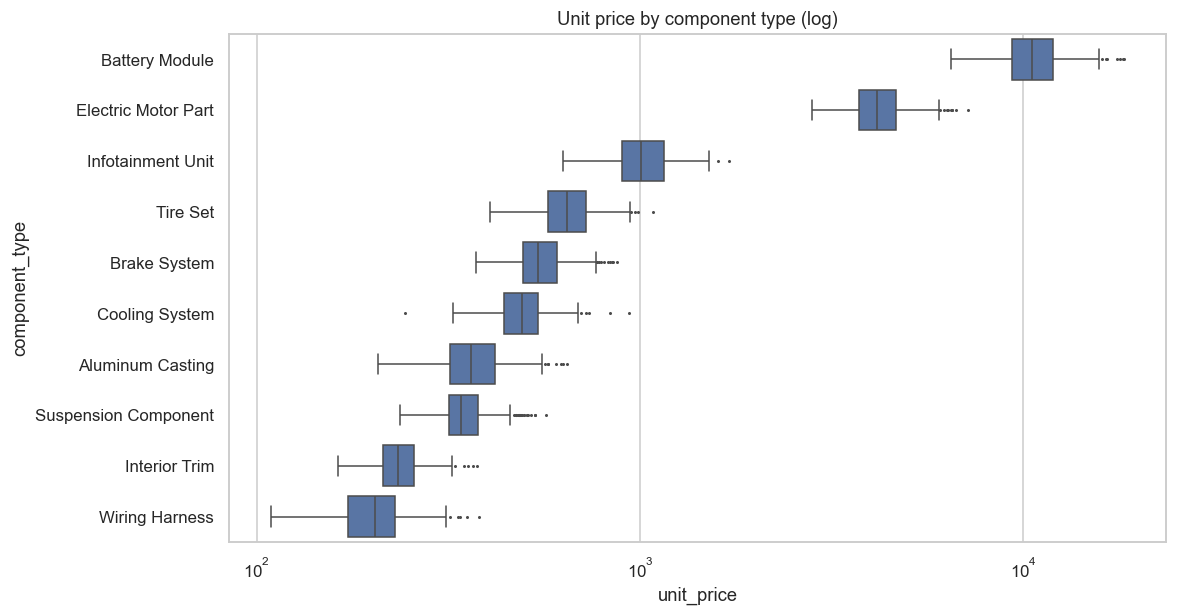

In [5]:
order = q.groupby('component_type').unit_price.median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(11,6))
sns.boxplot(data=q, y='component_type', x='unit_price', order=order, color='#4c72b0', fliersize=1)
ax.set_xscale('log'); ax.set_title('Unit price by component type (log)'); plt.show()

Battery Module & Electric Motor Part dominate the price scale; commodities/energy/FX drive the variation *within* each component tier.